# Image Verification - Using Deep Face

In [2]:
# pip install deepface

In [3]:
import os
os.getcwd()


'/content'

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
from deepface import DeepFace
import cv2
import matplotlib.pyplot as plt
import pickle

img1_path = "/content/drive/MyDrive/emotion_detection/verify_1.jpg"
img2_path = "/content/drive/MyDrive/emotion_detection/verify_2.jpg"

result = DeepFace.verify(img1_path=img1_path, img2_path=img2_path)

# Save to .pkl
with open("/content/drive/MyDrive/emotion_detection/verify_face.pkl", "wb") as f:
    pickle.dump(result, f)

print(" Saved result to verify_face.pkl")
print("")


25-07-09 13:53:28 - Directory /root/.deepface has been created
25-07-09 13:53:28 - Directory /root/.deepface/weights has been created
25-07-09 13:53:31 - vgg_face_weights.h5 will be downloaded...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5
100%|██████████| 580M/580M [00:07<00:00, 75.9MB/s]


 Saved result to verify_face.pkl



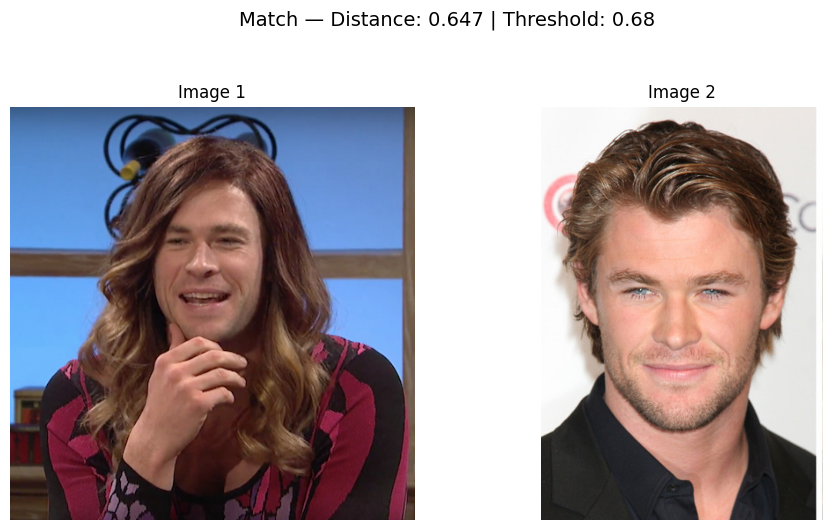

In [6]:
# Load images using OpenCV
img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)

# Convert to RGB for matplotlib
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Prepare title based on verification
title = "Match" if result["verified"] else "❌ No Match"
subtitle = f"Distance: {result['distance']:.3f} | Threshold: {result['threshold']}"

# Plot side by side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img1_rgb)
plt.title("Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2_rgb)
plt.title("Image 2")
plt.axis("off")

# Show result above
plt.suptitle(f"{title} — {subtitle}", fontsize=14, y=1.05)

plt.tight_layout()
plt.show()

In [ ]:
print(result)


{'verified': True, 'distance': -2.220446049250313e-16, 'threshold': 0.68, 'model': 'VGG-Face', 'detector_backend': 'opencv', 'similarity_metric': 'cosine', 'facial_areas': {'img1': {'x': 143, 'y': 92, 'w': 158, 'h': 158, 'left_eye': None, 'right_eye': None}, 'img2': {'x': 143, 'y': 92, 'w': 158, 'h': 158, 'left_eye': None, 'right_eye': None}}, 'time': 2.24}
